In [1]:
!pip install -q sentence-transformers seaborn

from sentence_transformers import SentenceTransformer, util
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
sentences = [
    # Cricket (3+)
    "The opener scored a century in the first innings.",
    "The fast bowler swung the new ball under the lights.",
    "The captain set an aggressive field for the final over.",
    "The spinner tricked the batsman with a googly.",

    # Cooking (3+)
    "The chef slow-cooked the lamb with fresh rosemary.",
    "She baked a chocolate cake with a rich ganache frosting.",
    "The recipe starts by sautéing onions and garlic in olive oil.",

    # Cybersecurity (3+)
    "The company enabled multi-factor authentication for all employees.",
    "The attacker tried to steal data using a phishing email.",
    "The security team monitored network traffic for unusual activity."
]

len(sentences)


10

In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = model.encode(sentences, convert_to_tensor=True)
embeddings.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

torch.Size([10, 384])

In [4]:
# Compute cosine similarity matrix
cosine_sim_matrix = util.cos_sim(embeddings, embeddings)

# Turn into a DataFrame for readability
df_sim = pd.DataFrame(
    cosine_sim_matrix.cpu().numpy(),
    index=[f"Sent {i}" for i in range(1, 11)],
    columns=[f"Sent {i}" for i in range(1, 11)]
)

df_sim


,Sent 1,Sent 2,Sent 3,Sent 4,Sent 5,Sent 6,Sent 7,Sent 8,Sent 9,Sent 10
Sent 1,1.000000,0.353336,0.323974,0.312856,0.108277,0.076885,0.104015,0.001685,0.063977,-0.012688
Sent 2,0.353336,1.000000,0.299425,0.423872,0.151885,0.081918,0.092473,0.073259,0.075236,0.141525
Sent 3,0.323974,0.299425,1.000000,0.339537,0.061388,-0.046664,0.015704,0.033997,0.019108,0.150586
Sent 4,0.312856,0.423872,0.339537,1.000000,0.097959,0.112046,0.077171,0.063798,0.185737,0.121574
Sent 5,0.108277,0.151885,0.061388,0.097959,1.000000,0.172001,0.403061,-0.003978,0.084384,-0.040420
Sent 6,0.076885,0.081918,-0.046664,0.112046,0.172001,1.000000,0.173917,0.067130,0.101570,-0.060648
Sent 7,0.104015,0.092473,0.015704,0.077171,0.403061,0.173917,1.000000,-0.000871,0.026066,0.074365
Sent 8,0.001685,0.073259,0.033997,0.063798,-0.003978,0.067130,-0.000871,1.000000,0.278311,0.258844
Sent 9,0.063977,0.075236,0.019108,0.185737,0.084384,0.101570,0.026066,0.278311,1.000000,0.288218
Sent 10,-0.012688,0.141525,0.150586,0.121574,-0.040420,-0.060648,0.074365,0.258844,0.288218,1.000000


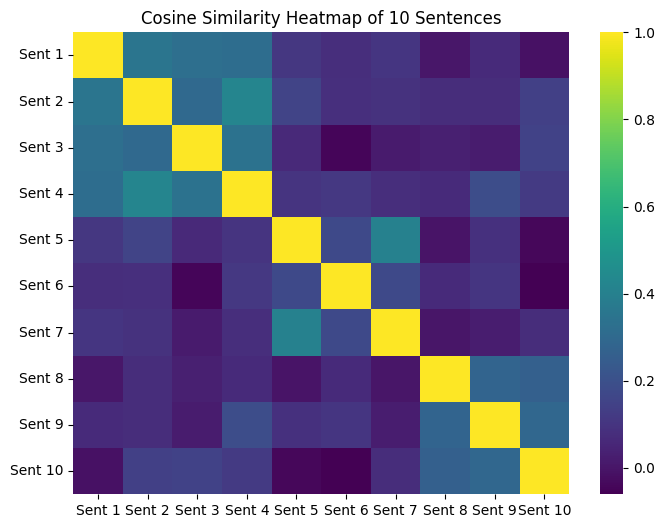

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=False, cmap="viridis")
plt.title("Cosine Similarity Heatmap of 10 Sentences")
plt.show()


In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity between query and each of the 10 sentences
cosine_scores = util.cos_sim(query_embedding, embeddings)[0]

# Get top 2 most similar
top_results = torch.topk(cosine_scores, k=2)

for score, idx in zip(top_results.values, top_results.indices):
    print(f"Sentence: {sentences[int(idx)]}")
    print(f"Similarity score: {float(score):.4f}")
    print("---")


Sentence: The fast bowler swung the new ball under the lights.
Similarity score: 0.5527
---
Sentence: The opener scored a century in the first innings.
Similarity score: 0.4804
---
